# OpenAlex API Exploration

Target researcher: Yuichi Tanaka

OpenAlex REST API docs: https://docs.openalex.org

## 0. Setup

In [20]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter
import time

BASE_URL = "https://api.openalex.org"

# OpenAlex polite pool: User-Agentヘッダにメールアドレスを設定する
# レートリミットが緩和され、安定したサービスを受けられる
EMAIL = "r.ikura@msp-lab.org"
HEADERS = {"User-Agent": f"mailto:{EMAIL}"}


def get(endpoint, params=None):
    """polite-poolヘッダ付きGETリクエスト。エラー時は例外を送出する。"""
    url = f"{BASE_URL}{endpoint}"
    resp = requests.get(url, params=params, headers=HEADERS)
    resp.raise_for_status()
    return resp.json()


def paginate(endpoint, params=None, max_results=None):
    """リストエンドポイントの全ページを取得してフラットなリストで返す。"""
    params = dict(params or {})
    params.setdefault("per_page", 200)
    params["cursor"] = "*"
    results = []
    while True:
        data = get(endpoint, params)
        batch = data["results"]
        results.extend(batch)
        if max_results and len(results) >= max_results:
            results = results[:max_results]
            break
        next_cursor = data.get("meta", {}).get("next_cursor")
        if not next_cursor:
            break
        params["cursor"] = next_cursor
        time.sleep(0.1)  # 連続リクエストの待機間隔
    return results

## 1. Author Search

Search for 'Yuichi Tanaka' and inspect candidate profiles.

In [21]:
search_result = get("/authors", {"search": "Yuichi Tanaka", "per_page": 10})

candidates = search_result["results"]
print(f"Total matching authors: {search_result['meta']['count']}")
print(f"Showing top {len(candidates)}:\n")

for a in candidates:
    affil = a.get("last_known_institutions", [])
    affil_name = affil[0]["display_name"] if affil else "N/A"
    print(
        f"  ID:          {a['id']}"
        f"\n  Name:        {a['display_name']}"
        f"\n  Works count: {a['works_count']}"
        f"\n  Citations:   {a['cited_by_count']}"
        f"\n  Affiliation: {affil_name}"
        f"\n  ORCID:       {a.get('orcid', 'N/A')}"
        f"\n"
    )

Total matching authors: 31
Showing top 10:

  ID:          https://openalex.org/A5007311789
  Name:        Yuichi Tanaka
  Works count: 295
  Citations:   2627
  Affiliation: Osaka University of Economics
  ORCID:       https://orcid.org/0000-0003-4010-3154

  ID:          https://openalex.org/A5101751423
  Name:        Yuichi Tanaka
  Works count: 88
  Citations:   1978
  Affiliation: Nagoya University
  ORCID:       https://orcid.org/0000-0003-1554-2331

  ID:          https://openalex.org/A5101751422
  Name:        Yuichi Tanaka
  Works count: 193
  Citations:   1732
  Affiliation: Tohoku University
  ORCID:       https://orcid.org/0000-0003-0651-2261

  ID:          https://openalex.org/A5101751424
  Name:        Yuichi Tanaka
  Works count: 87
  Citations:   535
  Affiliation: Kyushu University
  ORCID:       https://orcid.org/0009-0004-2476-5670

  ID:          https://openalex.org/A5051604128
  Name:        Y. Tanaka
  Works count: 28
  Citations:   347
  Affiliation: N/A
  ORCI

In [22]:
# 上のセルの結果を確認して、正しいAuthor IDをここに設定する
# フルURL（例: "https://openalex.org/A5023888391"）でも短縮ID（例: "A5023888391"）でも可
AUTHOR_ID = "A5007311789"  # <-- 上のセルを実行した後に入力する

# フルURLが貼り付けられた場合でも短縮IDに統一する
AUTHOR_ID = AUTHOR_ID.strip().split("/")[-1]
print(f"使用するAuthor ID: {AUTHOR_ID}")

使用するAuthor ID: A5007311789


## 2. Author Profile

In [23]:
author = get(f"/authors/{AUTHOR_ID}")

print("=== Author Profile ===")
print(f"Name:          {author['display_name']}")
print(f"ORCID:         {author.get('orcid', 'N/A')}")
print(f"Works count:   {author['works_count']}")
print(f"Citations:     {author['cited_by_count']}")
print(f"H-index:       {author.get('summary_stats', {}).get('h_index', 'N/A')}")
print(f"i10-index:     {author.get('summary_stats', {}).get('i10_index', 'N/A')}")
print(f"2yr mean citedness: {author.get('summary_stats', {}).get('2yr_mean_citedness', 'N/A')}")

print("\nAffiliation history:")
for inst in author.get("affiliations", []):
    years = inst.get("years", [])
    year_str = f"{min(years)}–{max(years)}" if years else "unknown"
    print(f"  {year_str}  {inst['institution']['display_name']}")

print("\nAlternative names:")
for nm in author.get("display_name_alternatives", []):
    print(f"  {nm}")

=== Author Profile ===
Name:          Yuichi Tanaka
ORCID:         https://orcid.org/0000-0003-4010-3154
Works count:   295
Citations:     2627
H-index:       21
i10-index:     56
2yr mean citedness: 0.3

Affiliation history:
  1987–1987  Dokkyo University
  2025–2025  Osaka Gakuin University
  2018–2018  Tokyo Institute of Technology
  2009–2009  Kogakuin University
  2020–2020  University of Southern California
  2009–2009  Canon (Japan)
  2023–2026  Osaka University of Economics
  2015–2015  University of Tsukuba
  2014–2022  Tokyo University of Technology
  2007–2009  Chiba University
  2000–2001  Taiyo Yuden (Japan)
  2005–2009  Keio University
  2008–2013  Utsunomiya University
  2000–2000  Saitama Prefecture
  2020–2020  California Southern University
  2014–2014  RIKEN Center for Brain Science
  2010–2015  National Institute of Technology, Kumamoto College
  2023–2026  Osaka City University
  2013–2013  University of Malaya
  2008–2008  University of California San Diego
  2017

## 3. Publications

In [24]:
# AUTHOR_ID が未設定だと filter=author.id: が空になり 400 エラーになる
# ここで明示的にチェックして分かりやすいメッセージを出す
assert AUTHOR_ID, "AUTHOR_ID が空です。上の '1. Author Search' の結果から正しいIDを cell に設定してください。"

works_raw = paginate(
    "/works",
    {
        "filter": f"author.id:{AUTHOR_ID}",
        "sort": "publication_year:desc",
        "select": "id,title,publication_year,cited_by_count,primary_location,authorships,concepts,open_access,type",
    },
)

print(f"Total works fetched: {len(works_raw)}")
if not works_raw:
    print("警告: 論文が0件です。AUTHOR_ID が正しいか確認してください。")

Total works fetched: 296


In [25]:
def extract_work(w):
    source = (w.get("primary_location") or {}).get("source") or {}
    return {
        "id": w["id"],
        "title": w["title"],
        "year": w["publication_year"],
        "type": w.get("type"),
        "cited_by_count": w["cited_by_count"],
        "source_name": source.get("display_name"),
        "source_type": source.get("type"),
        "is_oa": (w.get("open_access") or {}).get("is_oa"),
        "author_count": len(w.get("authorships", [])),
        # author.id が None の著者（名寄せ未確定）が混ざるため、None を空文字に変換してから比較する
        "author_position": next(
            (
                a["author_position"]
                for a in w.get("authorships", [])
                if AUTHOR_ID in ((a.get("author") or {}).get("id") or "")
            ),
            None,
        ),
    }


works_df = pd.DataFrame([extract_work(w) for w in works_raw])
works_df.head(10)

,id,title,year,type,cited_by_count,source_name,source_type,is_oa,author_count,author_position
0,https://openalex.org/W7161935281,Joint Alignment and Denoising for Event-Based ...,2026.0,preprint,0,arXiv (Cornell University),repository,True,4,last
1,https://openalex.org/W7162150159,Joint Alignment and Denoising for Event-Based ...,2026.0,article,0,ArXiv.org,repository,True,4,last
2,https://openalex.org/W7155060253,A Light-Weight PRNU-Based Camera-Device Authen...,2026.0,article,0,None,None,False,8,middle
3,https://openalex.org/W7160640033,PHISWID: physics-inspired underwater image dat...,2026.0,article,0,APSIPA Transactions on Signal and Information ...,journal,True,4,last
4,https://openalex.org/W4416047894,Algorithm Unrolling-Based Denoising of Multimo...,2026.0,preprint,0,IEEE Transactions on Signal and Information Pr...,journal,True,7,last
5,https://openalex.org/W4417467476,Graph Signal Denoising Using Regularization by...,2025.0,preprint,0,ArXiv.org,repository,True,3,last
6,https://openalex.org/W4415714287,Serial dependence in the perception of proportion,2025.0,preprint,0,bioRxiv (Cold Spring Harbor Laboratory),repository,True,3,middle
7,https://openalex.org/W4416798884,Period Estimation for Time-Varying Graph Signa...,2025.0,article,0,None,None,False,4,last
8,https://openalex.org/W4416798918,Unrolled Multimodal Signal Restoration with Si...,2025.0,article,0,None,None,False,3,last
9,https://openalex.org/W4416799344,Directed Graph Dynamic Mode Decomposition for ...,2025.0,article,0,None,None,False,6,middle


In [26]:
print("--- Basic stats ---")
print(works_df[["year", "cited_by_count", "author_count"]].describe().round(1))

print("\n--- Work types ---")
print(works_df["type"].value_counts().to_string())

print("\n--- Author position distribution ---")
print(works_df["author_position"].value_counts().to_string())

print("\n--- Open access ratio ---")
print(works_df["is_oa"].value_counts(normalize=True).round(3).to_string())

--- Basic stats ---
         year  cited_by_count  author_count
count   295.0           296.0         296.0
mean   2013.1             8.9           3.8
std      10.4            32.1           2.4
min    1961.0             0.0           1.0
25%    2009.0             0.0           3.0
50%    2015.0             1.0           3.0
75%    2020.0             6.0           4.0
max    2026.0           425.0          25.0

--- Work types ---
type
article         261
preprint         27
book-chapter      3
other             2
paratext          2
book              1

--- Author position distribution ---
author_position
last      131
middle    101
first      64

--- Open access ratio ---
is_oa
False    0.659
True     0.341


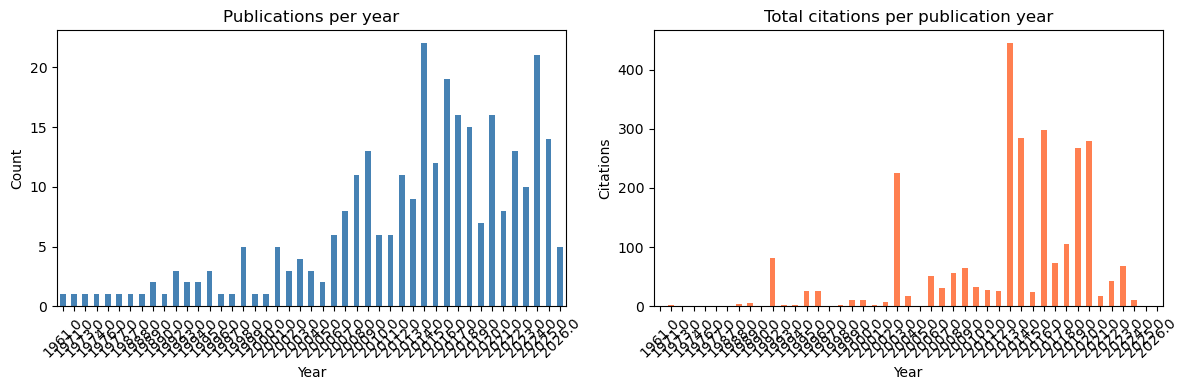

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 年別論文数
pub_by_year = works_df.groupby("year").size()
pub_by_year.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Publications per year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# 年別引用数の合計
cite_by_year = works_df.groupby("year")["cited_by_count"].sum()
cite_by_year.plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Total citations per publication year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Citations")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [28]:
print("Top 10 most cited works:")
top10 = works_df.nlargest(10, "cited_by_count")[["year", "cited_by_count", "source_name", "title"]]
top10["title"] = top10["title"].str[:80]
print(top10.to_string(index=False))

Top 10 most cited works:
  year  cited_by_count                                                          source_name                                                                            title
2013.0             425             Journal of Geotechnical and Geoenvironmental Engineering Shear-Wave Velocity–Based Probabilistic and Deterministic Assessment of Seismic 
2003.0             225                                 IEICE Transactions on Communications         Indoor Visible Light Data Transmission System Utilizing White LED Lights
2020.0             144                                      IEEE Signal Processing Magazine                          Sampling Signals on Graphs: From Theory to Applications
2019.0             106                               IEEE Transactions on Signal Processing                 Eigendecomposition-Free Sampling Set Selection for Graph Signals
2016.0             103 IEEE Transactions on Signal and Information Processing over Networks            Graph S

## 4. Citation Analysis

Pick the most-cited paper and retrieve:
- Papers it cites (references)
- Papers that cite it (cited_by)

In [29]:
top_work_row = works_df.nlargest(1, "cited_by_count").iloc[0]
top_work_id = top_work_row["id"].split("/")[-1]  # URLプレフィックスを除去する
print(f"Target paper: {top_work_row['title'][:80]}")
print(f"OpenAlex ID:  {top_work_id}")
print(f"Cited by:     {top_work_row['cited_by_count']}")

Target paper: Shear-Wave Velocity–Based Probabilistic and Deterministic Assessment of Seismic 
OpenAlex ID:  W2115364046
Cited by:     425


In [30]:
# この論文が引用している論文（参考文献）
top_work_detail = get(f"/works/{top_work_id}")
referenced_ids = top_work_detail.get("referenced_works", [])
print(f"References in this paper: {len(referenced_ids)}")

# 参考文献の詳細をバッチで取得（IDをパイプ区切りで指定）
ref_records = []
batch_size = 50
for i in range(0, min(len(referenced_ids), 200), batch_size):
    batch_ids = "|".join(r.split("/")[-1] for r in referenced_ids[i : i + batch_size])
    data = get("/works", {"filter": f"ids.openalex:{batch_ids}", "per_page": batch_size,
                          "select": "id,title,publication_year,cited_by_count,primary_location"})
    ref_records.extend(data["results"])
    time.sleep(0.1)

refs_df = pd.DataFrame([
    {
        "id": r["id"],
        "title": r["title"],
        "year": r["publication_year"],
        "cited_by_count": r["cited_by_count"],
        "source": ((r.get("primary_location") or {}).get("source") or {}).get("display_name"),
    }
    for r in ref_records
])

print(f"\nTop 10 most-cited references:")
top_refs = refs_df.nlargest(10, "cited_by_count")[["year", "cited_by_count", "title"]]
top_refs["title"] = top_refs["title"].str[:70]
print(top_refs.to_string(index=False))

References in this paper: 65

Top 10 most-cited references:
 year  cited_by_count                                                                  title
 2000          352998                R: A Language and Environment for Statistical Computing
 1975            3885                            Bayesian Inference in Statistical Analysis.
 1971            2868        Simplified Procedure for Evaluating Soil Liquefaction Potential
 1999            2692                                 Multichannel analysis of surface waves
 1977            2459                                The energy release in great earthquakes
 2001            1971 Liquefaction Resistance of Soils: Summary Report from the 1996 NCEER a
 1985            1322 Influence of SPT Procedures in Soil Liquefaction Resistance Evaluation
 1992            1157                             Bayesian Inference in Statistical Analysis
 1983             915      Evaluation of Liquefaction Potential Using Field Performance Data
 2000     

In [31]:
# この論文を引用している論文
cited_by_works = paginate(
    "/works",
    {
        "filter": f"cites:{top_work_id}",
        "sort": "cited_by_count:desc",
        "select": "id,title,publication_year,cited_by_count,primary_location,authorships",
    },
    max_results=200,
)

citing_df = pd.DataFrame([
    {
        "title": w["title"],
        "year": w["publication_year"],
        "cited_by_count": w["cited_by_count"],
        "source": ((w.get("primary_location") or {}).get("source") or {}).get("display_name"),
    }
    for w in cited_by_works
])

print(f"Papers citing this work (fetched): {len(citing_df)}")
print("\nTop 10 citing papers by citation count:")
top_citing = citing_df.nlargest(10, "cited_by_count")[["year", "cited_by_count", "title"]]
top_citing["title"] = top_citing["title"].str[:70]
print(top_citing.to_string(index=False))

print("\nCiting papers by year:")
print(citing_df["year"].value_counts().sort_index().to_string())

Papers citing this work (fetched): 200

Top 10 citing papers by citation count:
 year  cited_by_count                                                                  title
 2019             953 Earthquake‐Induced Chains of Geologic Hazards: Patterns, Mechanisms, a
 2019             195 A systematic review and meta-analysis of artificial neural network app
 2022             188 An investigation of feature selection methods for soil liquefaction pr
 2017             167        An Updated Geospatial Liquefaction Model for Global Application
 2022             144 Explainable machine learning model for liquefaction potential assessme
 2018             121 SPT-based probabilistic and deterministic assessment of seismic soil l
 2022             119 Liquefaction prediction with robust machine learning algorithms (SVM, 
 2022             117 Employing a genetic algorithm and grey wolf optimizer for optimizing R
 2021             110 Performance evaluation of hybrid GA–SVM and GWO–SVM models to

## 5. Coauthor Analysis

In [32]:
# 共著者を抽出するため著者情報付きで論文を再取得
works_with_authors = paginate(
    "/works",
    {
        "filter": f"author.id:{AUTHOR_ID}",
        "select": "id,publication_year,authorships",
    },
)

coauthor_counter = Counter()
coauthor_info = {}

for w in works_with_authors:
    for a in w.get("authorships", []):
        author_obj = a.get("author") or {}
        aid = author_obj.get("id")
        if not aid:
            continue  # author.id が None（名寄せ未確定）はスキップ
        if AUTHOR_ID in aid:
            continue  # 自分自身はスキップ
        coauthor_counter[aid] += 1
        coauthor_info[aid] = author_obj.get("display_name", aid)

print(f"Unique coauthors: {len(coauthor_counter)}")
print("\nTop 20 coauthors by collaboration count:")
top_coauthors = coauthor_counter.most_common(20)
for aid, count in top_coauthors:
    print(f"  {count:3d}  {coauthor_info[aid]}")

Unique coauthors: 332

Top 20 coauthors by collaboration count:
   31  Hiroshi Higashi
   29  Akie Sakiyama
   29  Masaaki Ikehara
   25  Madoka Hasegawa
   24  Shigeo Kato
   21  Masaki Onuki
   17  Antonio Ortega
   17  Seisuke Kyochi
   15  K. Yamada
   14  Taizo Suzuki
   13  Junya Hara
   13  Junya Hara
   11  Toshihisa Tanaka
   10  Truong Q. Nguyen
    9  Yonina C. Eldar
    9  Gene Cheung
    7  Shunsuke Ono
    7  Keiichiro Shirai
    7  Masaaki Ikehara
    6  Kenta Yanagiya


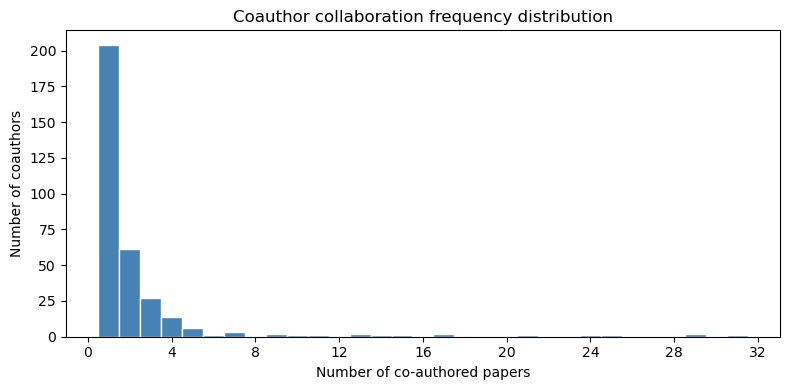

In [33]:
# 共著者との共著頻度のヒストグラム
counts = list(coauthor_counter.values())
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(counts, bins=range(1, max(counts) + 2), color="steelblue", edgecolor="white", align="left")
ax.set_title("Coauthor collaboration frequency distribution")
ax.set_xlabel("Number of co-authored papers")
ax.set_ylabel("Number of coauthors")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

## 6. Topic / Concept Analysis

In [34]:
# コンセプトタグ付きで論文を取得
works_with_concepts = paginate(
    "/works",
    {
        "filter": f"author.id:{AUTHOR_ID}",
        "select": "id,publication_year,concepts,topics",
    },
)

# --- Concepts（旧フィールド、細粒度）---
concept_counter = Counter()
concept_score = Counter()
for w in works_with_concepts:
    for c in w.get("concepts", []):
        concept_counter[c["display_name"]] += 1
        concept_score[c["display_name"]] += c.get("score", 0)

print("Top 20 concepts by frequency:")
for name, cnt in concept_counter.most_common(20):
    print(f"  {cnt:3d}  {name}")

Top 20 concepts by frequency:
  244  Computer science
  180  Mathematics
  162  Artificial intelligence
  149  Algorithm
  120  Computer vision
   92  Graph
   76  Filter (signal processing)
   73  Image (mathematics)
   70  Theoretical computer science
   57  Physics
   48  Materials science
   48  Pattern recognition (psychology)
   47  Mathematical analysis
   43  Geometry
   38  Engineering
   37  Wavelet
   36  Statistics
   36  Filter bank
   36  Composite material
   32  Telecommunications


In [35]:
# --- Topics（新しい構造化タクソノミー）---
topic_counter = Counter()
subfield_counter = Counter()
field_counter = Counter()
domain_counter = Counter()

for w in works_with_concepts:
    for t in w.get("topics", []):
        topic_counter[t.get("display_name", "")] += 1
        subfield_counter[t.get("subfield", {}).get("display_name", "")] += 1
        field_counter[t.get("field", {}).get("display_name", "")] += 1
        domain_counter[t.get("domain", {}).get("display_name", "")] += 1

print("Top 15 topics:")
for name, cnt in topic_counter.most_common(15):
    print(f"  {cnt:3d}  {name}")

print("\nTop 10 subfields:")
for name, cnt in subfield_counter.most_common(10):
    print(f"  {cnt:3d}  {name}")

print("\nFields:")
for name, cnt in field_counter.most_common():
    print(f"  {cnt:3d}  {name}")

print("\nDomains:")
for name, cnt in domain_counter.most_common():
    print(f"  {cnt:3d}  {name}")

Top 15 topics:
   80  Advanced Graph Neural Networks
   60  Image and Signal Denoising Methods
   49  Complex Network Analysis Techniques
   36  Digital Filter Design and Implementation
   33  Advanced Data Compression Techniques
   24  Graph Theory and Algorithms
   18  Advanced Image Fusion Techniques
   15  Image Enhancement Techniques
   12  Visual Attention and Saliency Detection
   11  Bayesian Modeling and Causal Inference
   11  Microstructure and Mechanical Properties of Steels
   11  Metallurgy and Material Forming
   11  Sparse and Compressive Sensing Techniques
   10  Bioinformatics and Genomic Networks
   10  EEG and Brain-Computer Interfaces

Top 10 subfields:
  213  Computer Vision and Pattern Recognition
  130  Artificial Intelligence
   56  Signal Processing
   51  Statistical and Nonlinear Physics
   44  Electrical and Electronic Engineering
   42  Mechanical Engineering
   24  Media Technology
   20  Cognitive Neuroscience
   20  Computational Mechanics
   16  Comput

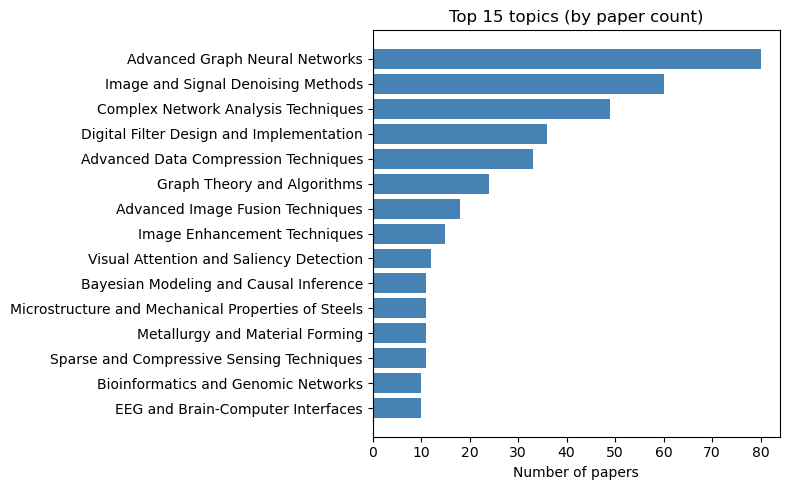

In [36]:
# トピック頻度の棒グラフ
top_topics = dict(topic_counter.most_common(15))
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(list(top_topics.keys())[::-1], list(top_topics.values())[::-1], color="steelblue")
ax.set_title("Top 15 topics (by paper count)")
ax.set_xlabel("Number of papers")
plt.tight_layout()
plt.show()

## 7. Journal / Venue Analysis

In [37]:
venue_counter = Counter(works_df["source_name"].dropna())
print("Top 15 publication venues:")
for name, cnt in venue_counter.most_common(15):
    print(f"  {cnt:3d}  {name}")

Top 15 publication venues:
   18  arXiv (Cornell University)
   10  IEEE Transactions on Signal Processing
    9  IEICE Technical Report; IEICE Tech. Rep.
    7  IEICE Transactions on Fundamentals of Electronics Communications and Computer Sciences
    5  ArXiv.org
    5  Journal of Japan Foundry Engineering Society
    4  IEEE Transactions on Signal and Information Processing over Networks
    4  ICASSP 2022 - 2022 IEEE International Conference on Acoustics, Speech and Signal Processing (ICASSP)
    4  Medical Entomology and Zoology
    4  Journal of the Japan Institute of Metals and Materials
    3  Japanese Journal of JSCE
    3  IEEE Access
    3  Journal of Japan Society of Civil Engineers Ser B3 (Ocean Engineering)
    2  APSIPA Transactions on Signal and Information Processing
    2  IEEE Open Journal of Signal Processing


## 8. Funding / Grant Analysis

OpenAlexでは、旧 `grants` フィールドではなく、現在はWork単位の `funders` と `awards` から資金情報を取得する。

- `funders`: 資金提供機関（例: JSPS, JST, NSF）
- `awards`: 助成番号・award ID（例: KAKENHIの課題番号、NSF award number）

ただし全論文に入っているわけではないため、まず充足率を確認する。


In [38]:
# Funding / grant相当の情報をWork単位で取得する
# OpenAlexの現在のAPIでは grants ではなく funders / awards を使う
funding_works_raw = paginate(
    "/works",
    {
        "filter": f"author.id:{AUTHOR_ID}",
        "sort": "publication_year:desc",
        "select": "id,title,publication_year,cited_by_count,type,funders,awards",
    },
)


def extract_funding_work(w):
    funders = w.get("funders") or []
    awards = w.get("awards") or []
    return {
        "id": w["id"],
        "title": w.get("title"),
        "year": w.get("publication_year"),
        "type": w.get("type"),
        "cited_by_count": w.get("cited_by_count"),
        "has_funders": bool(funders),
        "has_awards": bool(awards),
        "funder_count": len(funders),
        "award_count": len(awards),
        "funder_names": "; ".join(f.get("display_name", "") for f in funders),
        "award_numbers": "; ".join(a.get("funder_award_id") or "" for a in awards),
    }


funding_df = pd.DataFrame([extract_funding_work(w) for w in funding_works_raw])

print(f"Total works: {len(funding_df)}")
print(f"Works with funders: {funding_df['has_funders'].sum()} ({funding_df['has_funders'].mean():.1%})")
print(f"Works with awards:  {funding_df['has_awards'].sum()} ({funding_df['has_awards'].mean():.1%})")

# 資金情報が入っている論文を確認する
funding_df[funding_df["has_funders"] | funding_df["has_awards"]].head(20)


Total works: 296
Works with funders: 51 (17.2%)
Works with awards:  31 (10.5%)


,id,title,year,type,cited_by_count,has_funders,has_awards,funder_count,award_count,funder_names,award_numbers
1,https://openalex.org/W7162150159,Joint Alignment and Denoising for Event-Based ...,2026.0,article,0,True,True,1,3,Japan Society for the Promotion of Science,22H05163; 22K12500; 23H01415
8,https://openalex.org/W4416798918,Unrolled Multimodal Signal Restoration with Si...,2025.0,article,0,True,True,2,2,Japan Science and Technology Corporation; Japa...,25KJ1755; JPMJKB2307
15,https://openalex.org/W4408353424,Efficient Learning of Balanced Signed Graphs v...,2025.0,article,1,True,False,1,0,Natural Sciences and Engineering Research Coun...,
22,https://openalex.org/W4404295337,Denoising for Neuromorphic Cameras Based on Gr...,2024.0,article,1,True,True,1,3,Japan Society for the Promotion of Science,22H05163; 22K12500; 23H01415
23,https://openalex.org/W4402915488,Constructing an Interpretable Deep Denoiser by...,2024.0,article,0,True,False,1,0,Natural Sciences and Engineering Research Coun...,
24,https://openalex.org/W4404037540,Multiscale Graph Construction Using Non-Local ...,2024.0,preprint,0,True,True,1,1,Japan Society for the Promotion of Science,23K17461
25,https://openalex.org/W4403705628,Time-Varying Graph Signal Estimation among Mul...,2024.0,preprint,0,True,True,1,2,Japan Society for the Promotion of Science,23K26110; 23K17461
30,https://openalex.org/W4400703228,Edge Sampling of Graphs: Graph Signal Processi...,2024.0,preprint,0,True,True,1,1,Japan Society for the Promotion of Science,24KJ1577
33,https://openalex.org/W4392904315,Optimizing k in kNN Graphs with Graph Learning...,2024.0,article,3,True,True,2,5,National Science Foundation; Japan Society for...,2009032; 22H05163; 22K12500; 23H01415; CCF-200...
34,https://openalex.org/W4392902815,Lossy Compression of Adjacency Matrices by Gra...,2024.0,article,1,True,True,1,2,Japan Society for the Promotion of Science,JPMJSP2138; 23H01415


In [39]:
# funder / awardを論文単位から縦持ちデータに変換する
funder_rows = []
award_rows = []

for w in funding_works_raw:
    work_id = w.get("id")
    title = w.get("title")
    year = w.get("publication_year")
    cited_by_count = w.get("cited_by_count")

    for f in w.get("funders") or []:
        funder_rows.append({
            "work_id": work_id,
            "title": title,
            "year": year,
            "cited_by_count": cited_by_count,
            "funder_id": f.get("id"),
            "funder_name": f.get("display_name"),
            "funder_ror": f.get("ror"),
        })

    for a in w.get("awards") or []:
        award_rows.append({
            "work_id": work_id,
            "title": title,
            "year": year,
            "cited_by_count": cited_by_count,
            "award_id": a.get("id"),
            "award_title": a.get("display_name"),
            "award_number": a.get("funder_award_id"),
            "funder_id": a.get("funder_id"),
            "funder_name": a.get("funder_display_name"),
        })

funder_df = pd.DataFrame(funder_rows)
award_df = pd.DataFrame(award_rows)

print("Top funders by funded works:")
if len(funder_df):
    print(funder_df["funder_name"].value_counts().head(15).to_string())
else:
    print("No funder information found.")

print("\nTop award numbers by linked works:")
if len(award_df):
    print(award_df["award_number"].value_counts().head(15).to_string())
else:
    print("No award information found.")


Top funders by funded works:
funder_name
Japan Society for the Promotion of Science                        36
Precursory Research for Embryonic Science and Technology          11
Japan Science and Technology Agency                                6
National Science Foundation                                        4
Ministry of Education, Culture, Sports, Science and Technology     4
Natural Sciences and Engineering Research Council of Canada        3
Tokyo University of Agriculture and Technology                     3
Tokyo University of Agriculture                                    2
Japan Society for the Promotion of Science London                  2
U.S. Geological Survey                                             1
Tateishi Science and Technology Foundation                         1
Fundação para a Ciência e a Tecnologia                             1
Hong Kong Baptist University                                       1
Israel Science Foundation                                     

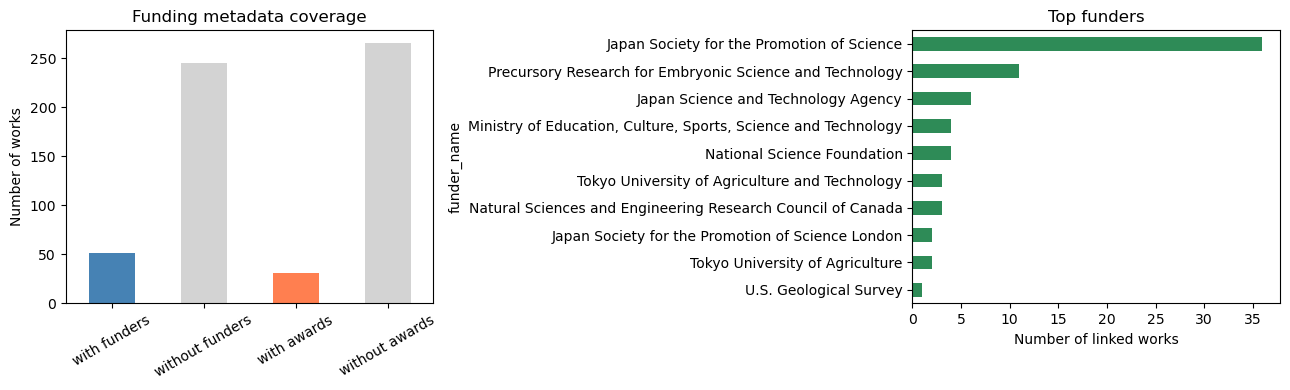

In [40]:
# grant/funding情報の可視化
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

coverage = pd.Series({
    "with funders": int(funding_df["has_funders"].sum()),
    "without funders": int((~funding_df["has_funders"]).sum()),
    "with awards": int(funding_df["has_awards"].sum()),
    "without awards": int((~funding_df["has_awards"]).sum()),
})
coverage.plot(kind="bar", ax=axes[0], color=["steelblue", "lightgray", "coral", "lightgray"])
axes[0].set_title("Funding metadata coverage")
axes[0].set_ylabel("Number of works")
axes[0].tick_params(axis="x", rotation=30)

if len(funder_df):
    top_funders = funder_df["funder_name"].value_counts().head(10).sort_values()
    top_funders.plot(kind="barh", ax=axes[1], color="seagreen")
    axes[1].set_title("Top funders")
    axes[1].set_xlabel("Number of linked works")
else:
    axes[1].text(0.5, 0.5, "No funder data", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


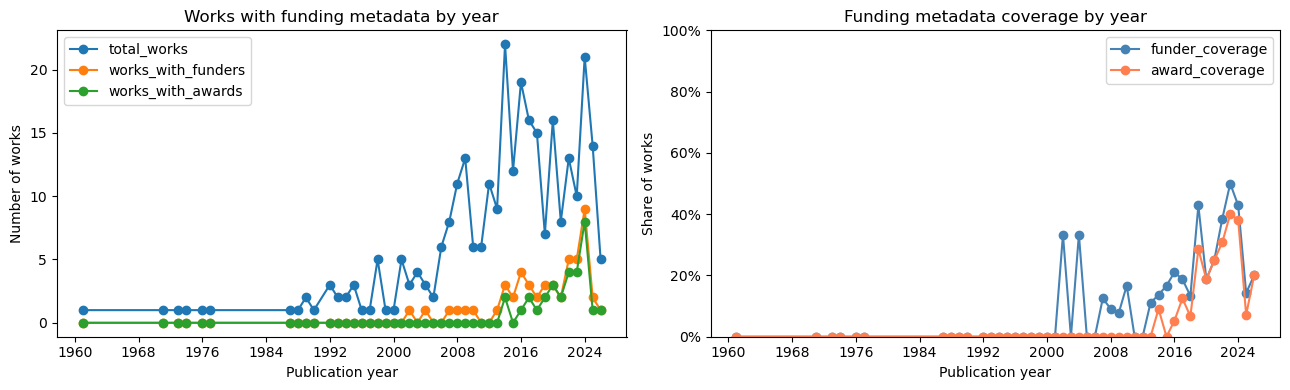

,total_works,works_with_funders,works_with_awards,funder_coverage,award_coverage
year,,,,,
2012.0,11,0,0,0.000000,0.000000
2013.0,9,1,0,0.111111,0.000000
2014.0,22,3,2,0.136364,0.090909
2015.0,12,2,0,0.166667,0.000000
2016.0,19,4,1,0.210526,0.052632
2017.0,16,3,2,0.187500,0.125000
2018.0,15,2,1,0.133333,0.066667
2019.0,7,3,2,0.428571,0.285714
2020.0,16,3,3,0.187500,0.187500


In [41]:
# 年別に、資金情報が入っている論文数と割合を見る
funding_by_year = (
    funding_df
    .groupby("year")
    .agg(
        total_works=("id", "count"),
        works_with_funders=("has_funders", "sum"),
        works_with_awards=("has_awards", "sum"),
    )
    .sort_index()
)
funding_by_year["funder_coverage"] = funding_by_year["works_with_funders"] / funding_by_year["total_works"]
funding_by_year["award_coverage"] = funding_by_year["works_with_awards"] / funding_by_year["total_works"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
funding_by_year[["total_works", "works_with_funders", "works_with_awards"]].plot(
    ax=axes[0], marker="o"
)
axes[0].set_title("Works with funding metadata by year")
axes[0].set_xlabel("Publication year")
axes[0].set_ylabel("Number of works")
axes[0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

funding_by_year[["funder_coverage", "award_coverage"]].plot(
    ax=axes[1], marker="o", color=["steelblue", "coral"]
)
axes[1].set_title("Funding metadata coverage by year")
axes[1].set_xlabel("Publication year")
axes[1].set_ylabel("Share of works")
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
axes[1].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

funding_by_year.tail(15)


In [42]:
# award IDから詳細情報を取得できるか確認する
# 例: 金額、通貨、助成期間、課題ページURLなどが入る場合がある
if len(award_df):
    sample_award_id = award_df["award_id"].dropna().iloc[0].split("/")[-1]
    sample_award = get(f"/awards/{sample_award_id}")

    sample_award_summary = {
        "id": sample_award.get("id"),
        "display_name": sample_award.get("display_name"),
        "funder_award_id": sample_award.get("funder_award_id"),
        "funder": (sample_award.get("funder") or {}).get("display_name"),
        "funded_outputs_count": sample_award.get("funded_outputs_count"),
        "amount": sample_award.get("amount"),
        "currency": sample_award.get("currency"),
        "funding_type": sample_award.get("funding_type"),
        "funder_scheme": sample_award.get("funder_scheme"),
        "start_year": sample_award.get("start_year"),
        "end_year": sample_award.get("end_year"),
        "landing_page_url": sample_award.get("landing_page_url"),
        "provenance": sample_award.get("provenance"),
    }
    pd.Series(sample_award_summary)
else:
    print("No award information found.")


### Funding / Grant情報の使い道と注意点

使えそうな分析:

- 外部資金あり/なしで、論文数・被引用数・共著者数・国際共著率が違うかを見る。
- JSPS、JST、NSFなどfunder別に、研究トピックや引用インパクトが違うかを見る。
- `award_id` 単位で成果論文をまとめ、1つの研究費からどのような論文群が出ているかを見る。
- Toyota関連研究では、公的助成が付いた論文と企業内部研究だけで出ている論文を分ける手がかりになる。

注意点:

- funding情報は全workに入っていないため、欠測率を必ず確認する。
- 論文謝辞やCrossrefなどのメタデータに依存するため、網羅的な研究費データではない。
- 企業内部の研究費、部署予算、共同研究契約の詳細は基本的に取れない。
- award番号と課題名の対応に誤りが混ざる可能性があるため、重要なケースはKAKEN等の外部DBで確認する。


## 9. Summary & Observations

Record findings and missing data here as a working memo.

In [43]:
print("=== Summary ===")
print(f"Author:           {author['display_name']}")
print(f"OpenAlex ID:      {AUTHOR_ID}")
print(f"ORCID:            {author.get('orcid', 'N/A')}")
print(f"Total works:      {len(works_df)}")
print(f"Total citations:  {works_df['cited_by_count'].sum()}")
print(f"H-index (OA):     {author.get('summary_stats', {}).get('h_index', 'N/A')}")
print(f"Active years:     {int(works_df['year'].min())} – {int(works_df['year'].max())}")
print(f"Unique coauthors: {len(coauthor_counter)}")
print(f"Unique venues:    {len(venue_counter)}")

=== Summary ===
Author:           Yuichi Tanaka
OpenAlex ID:      A5007311789
ORCID:            https://orcid.org/0000-0003-4010-3154
Total works:      296
Total citations:  2634
H-index (OA):     21
Active years:     1961 – 2026
Unique coauthors: 332
Unique venues:    92
